<a href="https://colab.research.google.com/github/1010999/OptiCrop-Smart-Agricultural-Production-Optimization-Engine/blob/main/opticrop_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ── Core data libraries ──────────────────────────────────────
import numpy as np               # numerical operations
import pandas as pd              # data manipulation (dataframes)

# ── Visualisation libraries ───────────────────────────────────
import matplotlib.pyplot as plt  # plotting charts
import seaborn as sns            # statistical visualisations

# ── Machine learning libraries ────────────────────────────────
from sklearn.cluster import KMeans                      # K-Means clustering
from sklearn.linear_model import LogisticRegression     # Logistic regression
from sklearn.model_selection import train_test_split    # split data
from sklearn.preprocessing import LabelEncoder          # encode crop names
from sklearn.metrics import accuracy_score, classification_report

# ── Model saving ─────────────────────────────────────────────
import pickle                    # save and load trained model

# ── Display settings ─────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')


In [5]:
# Load the dataset
df = pd.read_csv('/content/Crop_recommendation.csv')



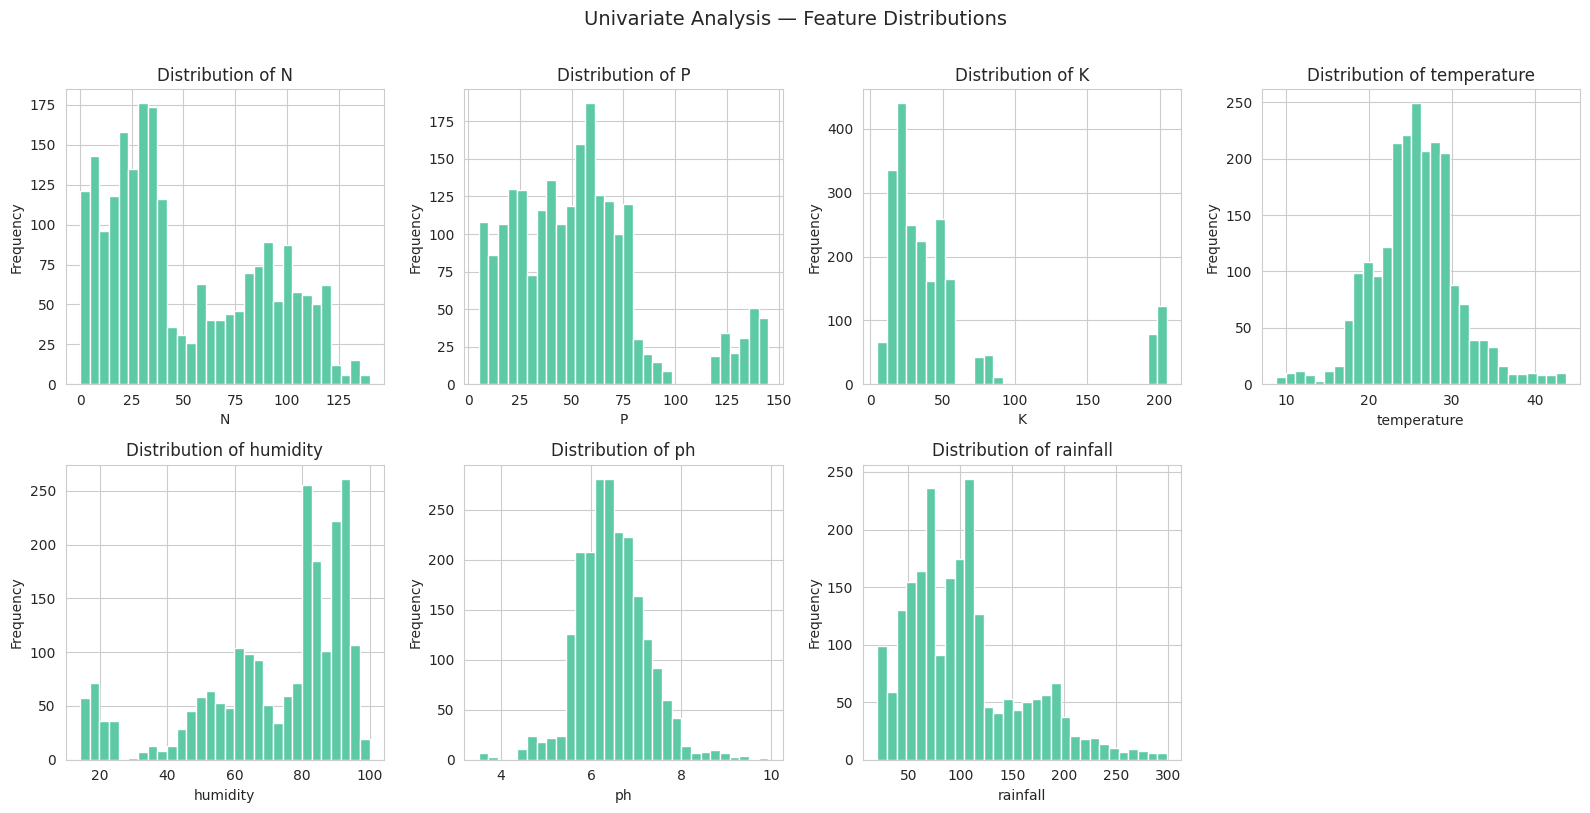

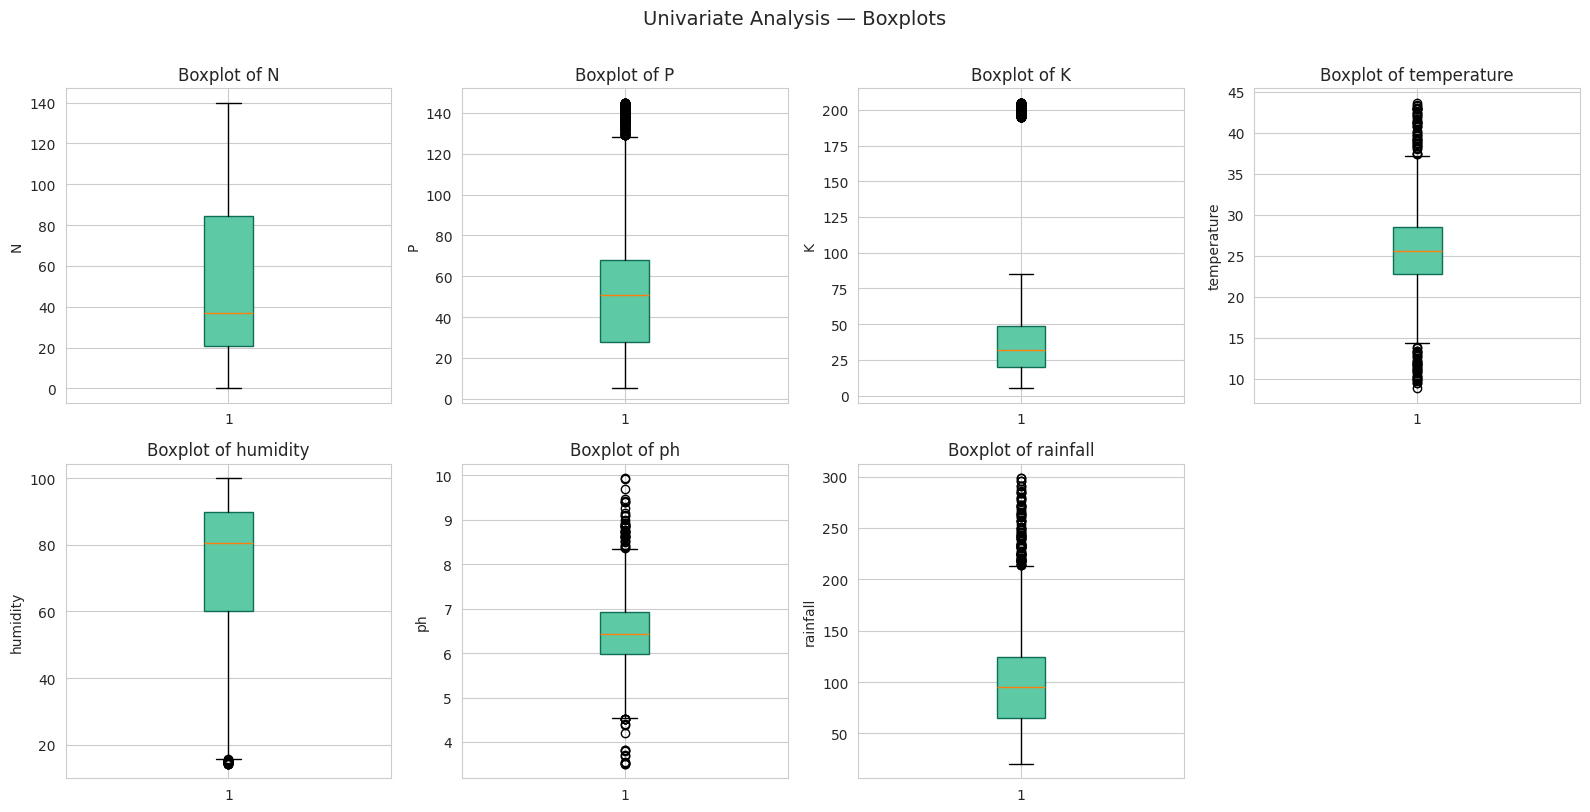

In [6]:
# ── Univariate Analysis ───────────────────────────────────────
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, color='#5DCAA5', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

axes[-1].axis('off')  # hide the last empty subplot
plt.suptitle('Univariate Analysis — Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Box plots to spot outliers
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='#5DCAA5', color='#0F6E56'))
    axes[i].set_title(f'Boxplot of {col}', fontsize=12)
    axes[i].set_ylabel(col)

axes[-1].axis('off')
plt.suptitle('Univariate Analysis — Boxplots', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

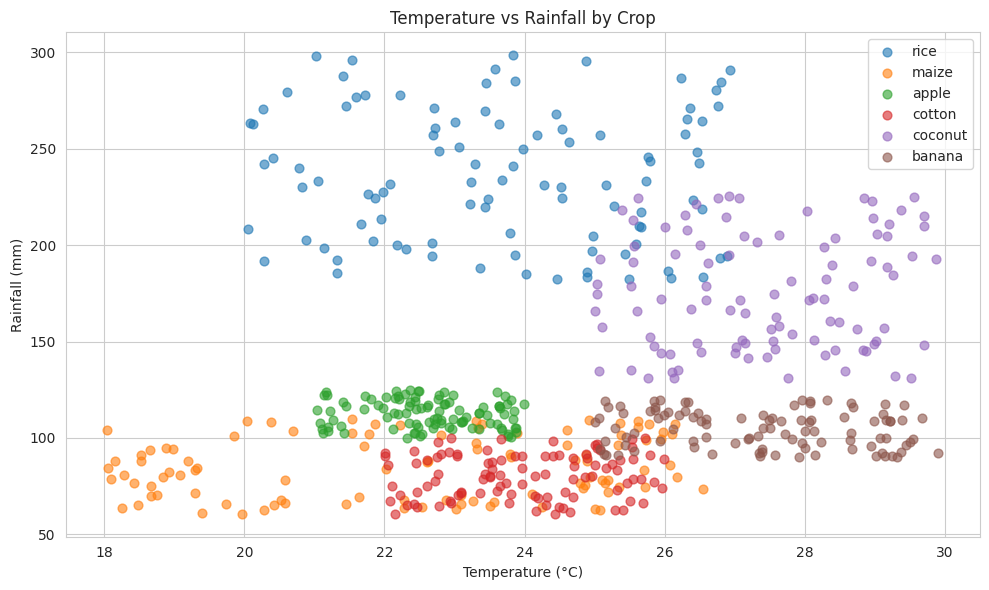

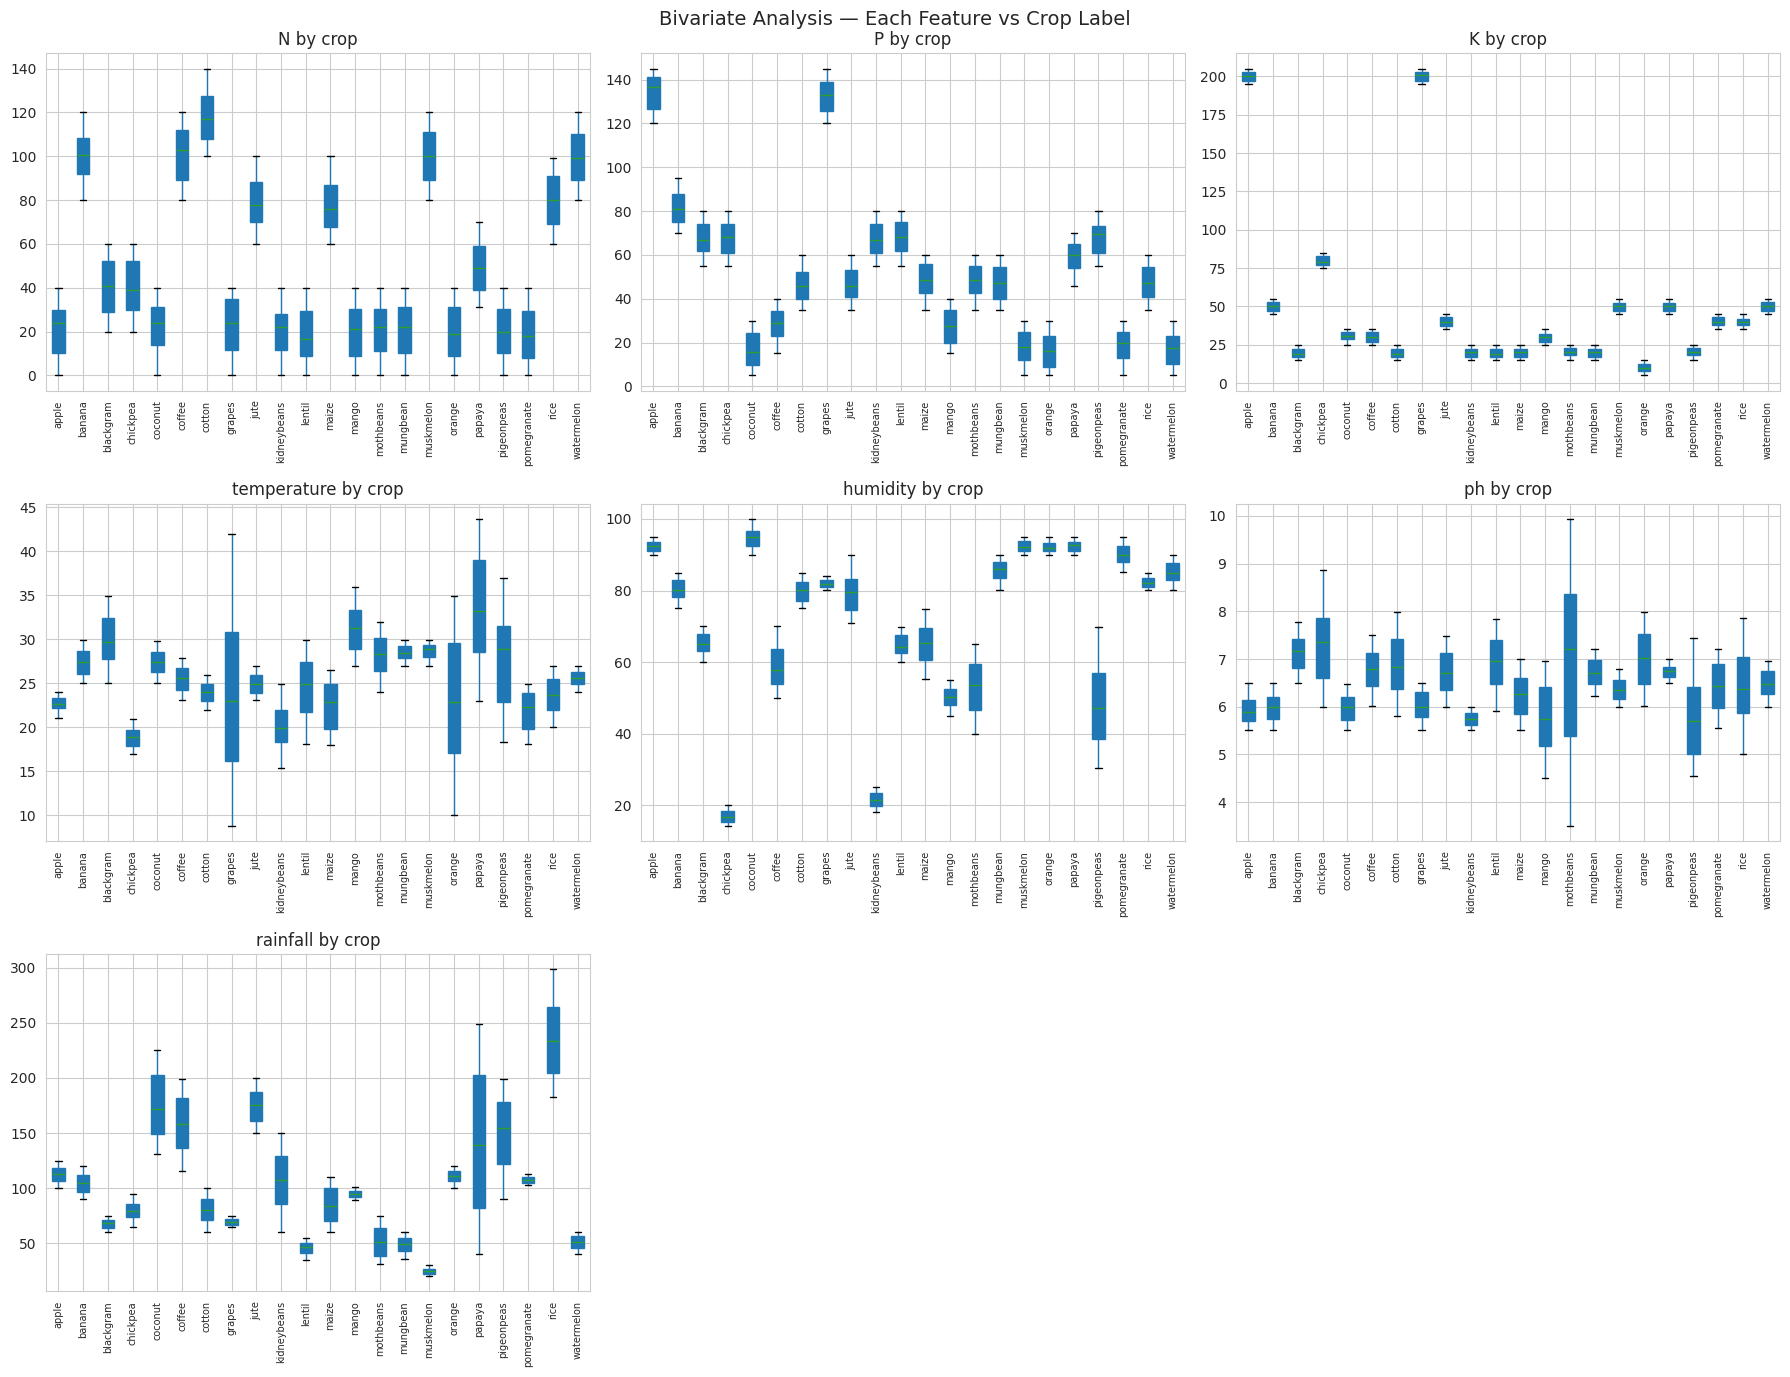


Mean feature values per crop:


,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
apple,20.80,134.22,199.89,22.63,92.33,5.93,112.65
banana,100.23,82.01,50.05,27.38,80.36,5.98,104.63
blackgram,40.02,67.47,19.24,29.97,65.12,7.13,67.88
chickpea,40.09,67.79,79.92,18.87,16.86,7.34,80.06
coconut,21.98,16.93,30.59,27.41,94.84,5.98,175.69
coffee,101.20,28.74,29.94,25.54,58.87,6.79,158.07
cotton,117.77,46.24,19.56,23.99,79.84,6.91,80.40
grapes,23.18,132.53,200.11,23.85,81.88,6.03,69.61
jute,78.40,46.86,39.99,24.96,79.64,6.73,174.79


In [7]:
# ── Bivariate Analysis ────────────────────────────────────────

# 1. Scatter plot: temperature vs rainfall, coloured by crop
plt.figure(figsize=(10, 6))
crops_to_show = ['rice', 'maize', 'apple', 'cotton', 'coconut', 'banana']
subset = df[df['label'].isin(crops_to_show)]

for crop in crops_to_show:
    data = subset[subset['label'] == crop]
    plt.scatter(data['temperature'], data['rainfall'],
                label=crop, alpha=0.6, s=40)

plt.xlabel('Temperature (°C)')
plt.ylabel('Rainfall (mm)')
plt.title('Temperature vs Rainfall by Crop')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Box plots per crop for each feature
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    df.boxplot(column=col, by='label', ax=axes[i],
               patch_artist=True)
    axes[i].set_title(f'{col} by crop')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=90, labelsize=7)

for j in range(len(features), len(axes)):
    axes[j].axis('off')

plt.suptitle('Bivariate Analysis — Each Feature vs Crop Label', fontsize=14)
plt.tight_layout()
plt.show()

# 3. Mean values per crop — useful summary table
print("\nMean feature values per crop:")
display(df.groupby('label').mean().round(2))

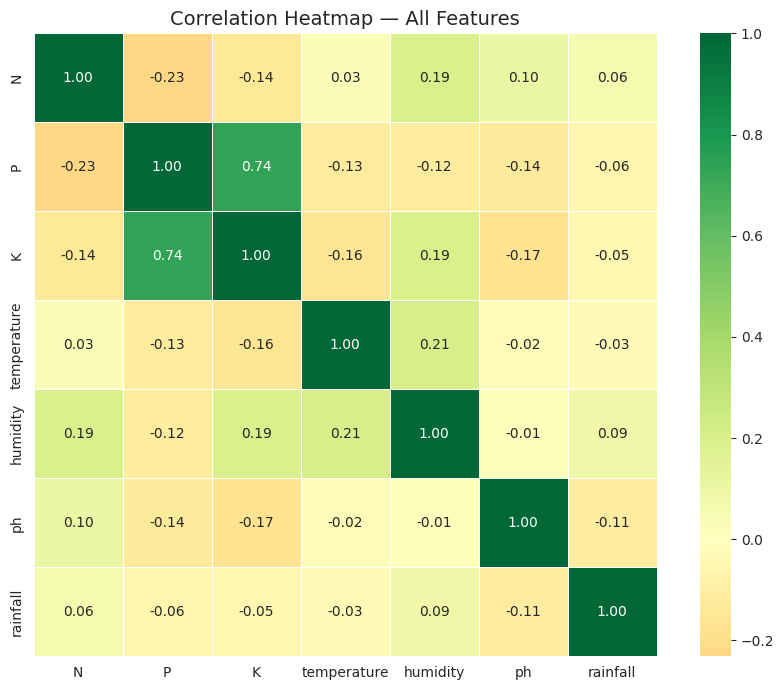

<Figure size 640x480 with 0 Axes>

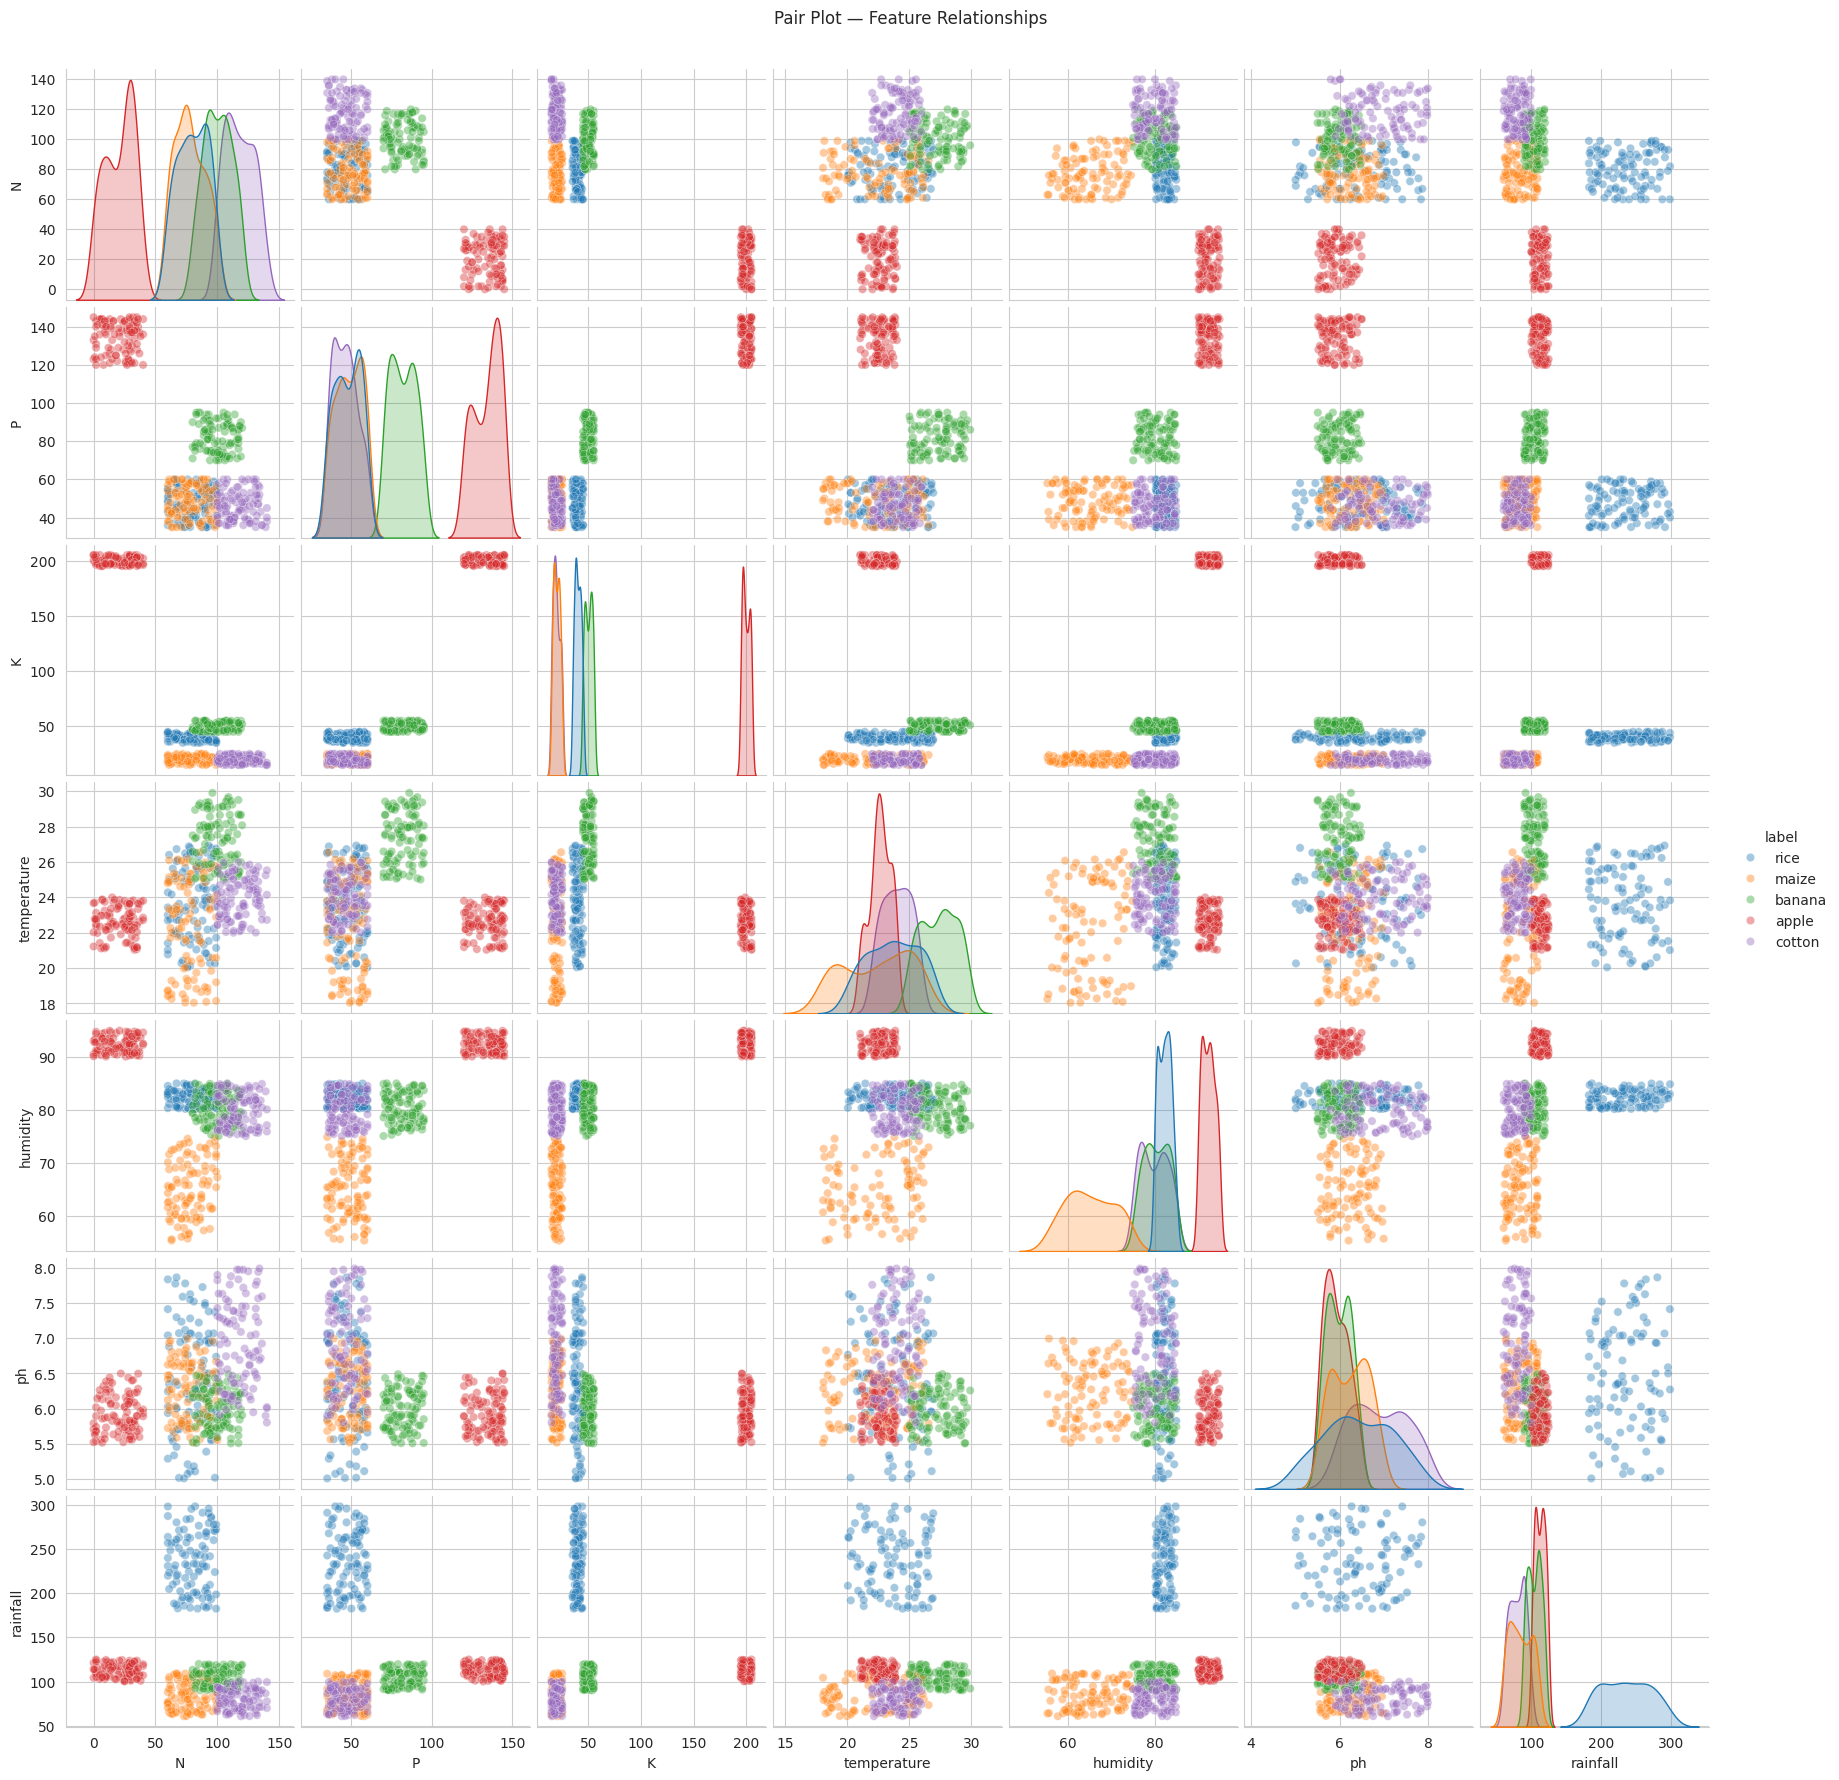

Feature correlation with target (label):
humidity       0.193911
temperature    0.113606
rainfall       0.045611
ph            -0.012253
N             -0.031130
K             -0.346417
P             -0.491006
Name: label_encoded, dtype: float64


In [10]:
# ── Multivariate Analysis ─────────────────────────────────────

# 1. Correlation heatmap
plt.figure(figsize=(9, 7))
corr = df[features].corr()
sns.heatmap(corr,
            annot=True,         # show numbers in cells
            fmt='.2f',          # 2 decimal places
            cmap='RdYlGn',      # red = negative, green = positive
            center=0,
            square=True,
            linewidths=0.5)
plt.title('Correlation Heatmap — All Features', fontsize=14)
plt.tight_layout()
plt.show()

# 2. Pair plot (scatter matrix) for a subset of crops
plt.figure()
subset = df[df['label'].isin(['rice', 'maize', 'cotton', 'apple', 'banana'])]
sns.pairplot(subset, hue='label', vars=features, plot_kws={'alpha':0.4})
plt.suptitle('Pair Plot — Feature Relationships', y=1.02)
plt.show()

# 3. Encode labels for correlation with target
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])
print("Feature correlation with target (label):")
print(df[features + ['label_encoded']].corr()['label_encoded']
        .drop('label_encoded').sort_values(ascending=False))

In [9]:
# How to handle nulls IF they existed (for your knowledge):

# Option 1 — Drop rows with nulls
df_clean = df.dropna()

# Option 2 — Fill nulls with column mean (for numeric columns)
df['N'] = df['N'].fillna(df['N'].mean())

# Option 3 — Fill nulls with median (better for skewed data like P, K, rainfall)
df['rainfall'] = df['rainfall'].fillna(df['rainfall'].median())

# Option 4 — Fill nulls with mode (for categorical columns)
df['label'] = df['label'].fillna(df['label'].mode()[0])

In [11]:
# ── Handling Outliers ─────────────────────────────────────────

features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
outlier_summary = []

for col in features:
    Q1 = df[col].quantile(0.25)   # 25th percentile
    Q3 = df[col].quantile(0.75)   # 75th percentile
    IQR = Q3 - Q1                  # interquartile range

    lower = Q1 - 1.5 * IQR        # lower fence
    upper = Q3 + 1.5 * IQR        # upper fence

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary.append({
        'Feature': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower fence': round(lower, 2),
        'Upper fence': round(upper, 2),
        'Outlier count': len(outliers)
    })

summary_df = pd.DataFrame(outlier_summary)
# Remove outliers using IQR
df_clean = df.copy()

for col in features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]





Season distribution:
season
Kharif    906
Zaid      740
Rabi      200
Name: count, dtype: int64



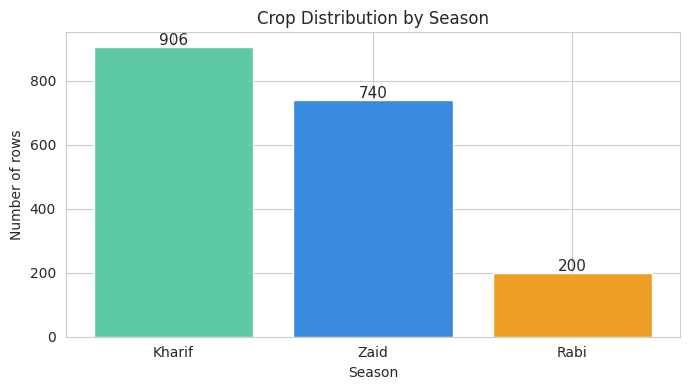

In [12]:
# ── Extracting Seasonal Crops ─────────────────────────────────

# Define season mapping
kharif_crops = ['rice', 'maize', 'chickpea', 'kidneybeans',
                'pigeonpeas', 'mothbeans', 'mungbean', 'blackgram',
                'cotton', 'jute']

rabi_crops   = ['lentil', 'wheat', 'mustard', 'barley',
                'pomegranate', 'grapes']

zaid_crops   = ['watermelon', 'muskmelon', 'cucumber', 'banana',
                'mango', 'orange', 'papaya', 'coconut', 'apple', 'coffee']

def get_season(crop):
    if crop in kharif_crops:
        return 'Kharif'
    elif crop in rabi_crops:
        return 'Rabi'
    else:
        return 'Zaid'

df_clean['season'] = df_clean['label'].apply(get_season)

print("Season distribution:")
print(df_clean['season'].value_counts())
print()

# Plot season distribution
plt.figure(figsize=(7, 4))
season_counts = df_clean['season'].value_counts()
colors = ['#5DCAA5', '#378ADD', '#EF9F27']
plt.bar(season_counts.index, season_counts.values, color=colors, edgecolor='white')
plt.title('Crop Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Number of rows')
for i, v in enumerate(season_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

In [13]:
# ── Train / Test Split ────────────────────────────────────────


# Separate features (X) and target label (y)
X = df_clean[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df_clean['label']

# Encode crop names to numbers (rice→0, maize→1, etc.)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Save the class names for later use in the app



# Split: 80% train, 20% test, random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded   # ensures each crop is proportionally represented
)



In [14]:
# ── K-Means Clustering ────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Scale features first — K-Means is distance-based, so scale matters
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find the best number of clusters using the Elbow Method
inertia = []
K_range = range(2, 25)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)



# Train K-Means with k=22 (one cluster per crop type)
kmeans = KMeans(n_clusters=22, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Add cluster labels to the dataframe
df_clean['cluster'] = kmeans.labels_

 # See which crops landed in which cluster

cluster_crop = df_clean.groupby('cluster')['label'].agg(
    lambda x: x.value_counts().index[0]
)


In [15]:
# ── Logistic Regression ───────────────────────────────────────
from sklearn.linear_model import LogisticRegression

# Train the model
log_reg = LogisticRegression(
    max_iter=1000,        # enough iterations to converge
    random_state=42,
    multi_class='auto',   # handles 22-class problem automatically
    solver='lbfgs'        # efficient solver for multi-class
)

log_reg.fit(X_train, y_train)

# Predict on the test set
y_pred = log_reg.predict(X_test)

print("Logistic Regression training complete!")
print(f"\nTraining accuracy: {log_reg.score(X_train, y_train)*100:.2f}%")
print(f"Testing accuracy:  {accuracy_score(y_test, y_pred)*100:.2f}%")

Logistic Regression training complete!

Training accuracy: 97.83%
Testing accuracy:  96.49%


Classification Report:
              precision    recall  f1-score   support

      banana       1.00      1.00      1.00        20
   blackgram       0.89      0.80      0.84        20
    chickpea       1.00      1.00      1.00        18
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      0.95      0.95        20
        jute       0.94      0.80      0.86        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.91      1.00      0.95        20
       maize       0.95      0.95      0.95        20
       mango       1.00      1.00      1.00        19
   mothbeans       0.83      0.83      0.83        12
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        16
      papaya       1.00      1.00      1.00        13
  pigeonpeas       1.00      1.00      1.00        19
 pom

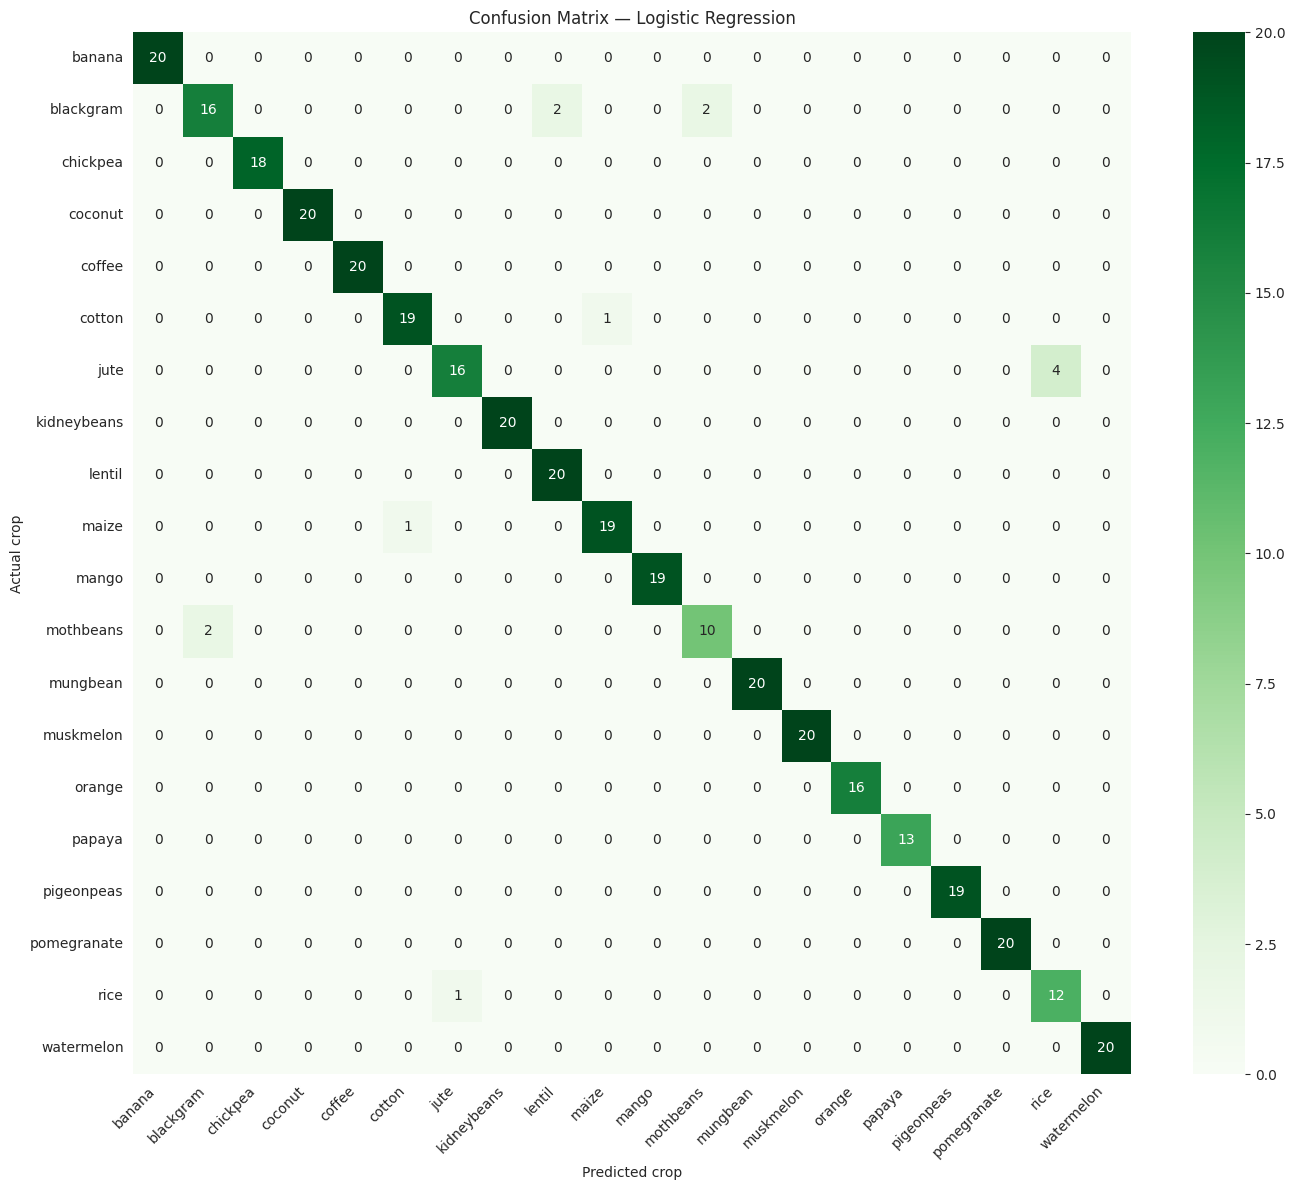


Model Comparison:
Model                      Train Acc   Test Acc
-----------------------------------------------
Logistic Regression           97.83%     96.49%


In [16]:
# ── Evaluation ────────────────────────────────────────────────
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix)
import seaborn as sns

# Full classification report
print("Classification Report:")
print(classification_report(y_test, y_pred,
                             target_names=le.classes_))

# Confusion matrix
plt.figure(figsize=(14, 12))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm,
            annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Greens')
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted crop')
plt.ylabel('Actual crop')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Model comparison table
print("\nModel Comparison:")
print(f"{'Model':<25} {'Train Acc':>10} {'Test Acc':>10}")
print("-" * 47)
print(f"{'Logistic Regression':<25} "
      f"{log_reg.score(X_train, y_train)*100:>9.2f}% "
      f"{accuracy_score(y_test, y_pred)*100:>9.2f}%")

In [17]:
# ── Save the Best Model ───────────────────────────────────────
import pickle
import os

os.makedirs('model', exist_ok=True)

# Save the trained Logistic Regression model
with open('model/crop_model.pkl', 'wb') as f:
    pickle.dump(log_reg, f)

# Save the label encoder (so we can decode predictions back to crop names)
with open('model/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Save the scaler (needed if we scale inputs in the app)
with open('model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

